In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [52]:
# Загрузка исторических данных

name = "BTCUSDT_1h_last_year"
filename = f"data/1h_last_year/{name}.csv"
data = pd.read_csv(filename, parse_dates=['timestamp'])
data.set_index('timestamp', inplace=True)
data.drop(['open', 'high', 'low', 'close_time', 'quote_asset_volume', 'number_of_trades', 'taker_buy_base_volume', 'taker_buy_quote_volume', 'ignore'], axis=1, inplace=True)

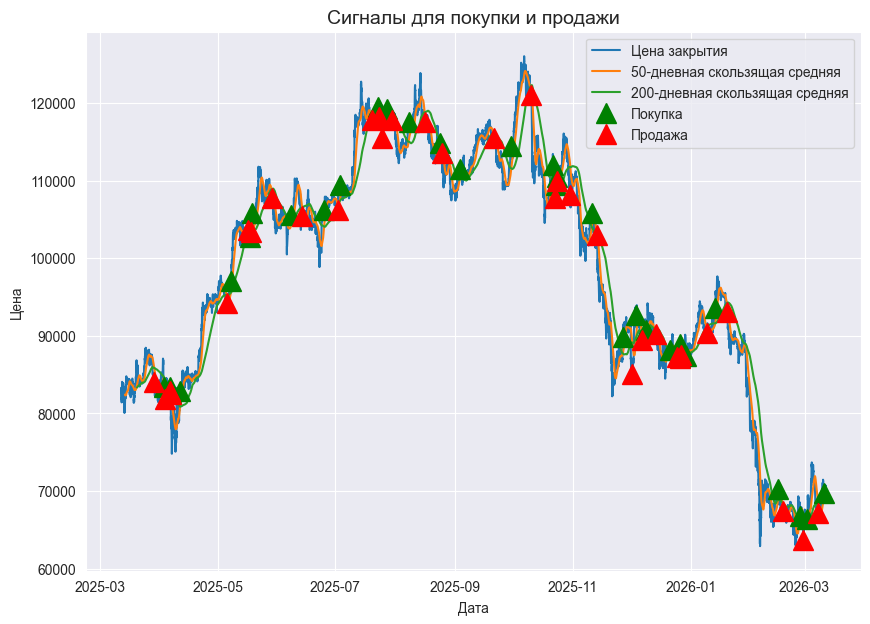

In [53]:
# Стратегия

short_window = 200
long_window = 50

data['SMA200'] = data['close'].rolling(window=short_window).mean()
data['SMA50'] = data['close'].rolling(window=long_window).mean()

# Сигналы для покупки

data['buy'] = np.where((data['SMA50'] >= data['SMA200']) & (data['SMA50'].shift(1) <= data['SMA200'].shift(1)), 1, 0)

# Сигналы для продажи
data['sell'] = np.where((data['SMA50'] <= data['SMA200']) & (data['SMA50'].shift(1) >= data['SMA200'].shift(1)), -1, 0)

data['signal'] = data['buy'] + data['sell']

plot_data = data
plt.figure(figsize=(10, 7))
plt.title('Сигналы для покупки и продажи', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Цена')
plt.plot(plot_data['close'], label='Цена закрытия')
plt.plot(plot_data['SMA50'], label='50-дневная скользящая средняя')
plt.plot(plot_data['SMA200'], label='200-дневная скользящая средняя')
plt.plot(plot_data[data['signal'] == 1]['close'],
'^', ms=15, label='Покупка', color='green')
plt.plot(plot_data[data['signal'] == -1]['close'],
'^', ms=15, label='Продажа', color='red')
plt.legend()
plt.show()

In [54]:
portfolio = pd.DataFrame(data=data[['signal', 'close']], index=data.index)

initial_portfolio_value = 100000
buy_percentage = 0.9
buy_mask = data['signal'].shift(1).fillna(0) == 1
sell_mask = data['signal'].shift(1).fillna(0) == -1

portfolio['trade_id'] = (portfolio['signal'] == 1).cumsum().shift(1)

portfolio['portfolio_value'] = initial_portfolio_value
portfolio['investment_amount'] = 0
portfolio['shares_held'] = 0
portfolio['sale_proceeds'] = 0
portfolio['shares_sold'] = 0

portfolio['buy_price'] = portfolio.groupby('trade_id')['close'].transform('first')
portfolio['after_sell'] = (portfolio[portfolio['trade_id'] > 0]['signal'] == -1).shift(1).fillna(0).cumsum()

# Шаг 1. Расчёт покупок
portfolio['investment_amount'] = np.where(
    buy_mask,
    portfolio['portfolio_value'].shift(1).fillna(initial_portfolio_value) * buy_percentage,
    0
)
portfolio['shares_bought'] = np.where(
    buy_mask,
    portfolio['investment_amount'] / data['close'],
    0
)
portfolio['sell_amount'] = portfolio.groupby('trade_id')['shares_bought'].transform('first')

# Шаг 2. Расчёт продаж
portfolio['shares_sold'] = np.where(
    sell_mask,
    portfolio['sell_amount'].shift(1).fillna(0),
    0
)
# Выручка от продажи
portfolio['sale_proceeds'] = np.where(
    sell_mask,
    portfolio['shares_sold'] * data['close'],
    0
)

# Общее количество купленных акций (кумулятивно)
cumulative_bought = portfolio['shares_bought'].cumsum()
# portfolio['cumulative_bought'] = cumulative_bought
# Общее количество проданных акций (кумулятивно)
cumulative_sold = portfolio['shares_sold'].cumsum()
# portfolio['cumulative_sold'] = cumulative_sold
# Текущее количество акций на руках
portfolio['shares_held'] = cumulative_bought - cumulative_sold
#
# Шаг 4. Расчёт денежных средств
# Деньги от продаж (кумулятивно)
total_sale_proceeds = portfolio['sale_proceeds'].cumsum()
# Деньги, потраченные на покупки (кумулятивно)
total_investments = portfolio['investment_amount'].cumsum()
#
# Денежный баланс: начальная сумма + продажи − покупки
portfolio['cash_balance'] = (
    initial_portfolio_value +
    total_sale_proceeds -
    total_investments
)

# Шаг 5. Расчёт стоимости портфеля
# Стоимость акций на текущем шаге
portfolio['stock_value'] = portfolio['shares_held'] * data['close']
# Итоговая стоимость портфеля: деньги + акции
portfolio['portfolio_value'] = portfolio['cash_balance'] + portfolio['stock_value']

#portfolio['2025-04-03': '2025-04-15'].head(20)
#portfolio['2025-03-29': '2025-04-15'].head(20)
#portfolio['2025-04-06': '2025-09-15'].head(20)
#portfolio['2025-05-25': '2025-06-10'].head(60)
portfolio.tail(20)



,signal,close,trade_id,portfolio_value,investment_amount,shares_held,sale_proceeds,shares_sold,buy_price,after_sell,shares_bought,sell_amount,cash_balance,stock_value
timestamp,,,,,,,,,,,,,,
2026-03-11 02:00:00,1,69810.72,32.0,107253.609779,0.0,0.000000,0.0,0.0,65963.43,32,0.000000,1.364392,107253.609779,0.000000
2026-03-11 03:00:00,0,69551.91,33.0,107253.609779,90000.0,1.293998,0.0,0.0,69551.91,32,1.293998,1.293998,17253.609779,90000.000000
2026-03-11 04:00:00,0,70130.99,33.0,108002.937871,0.0,1.293998,0.0,0.0,69551.91,32,0.000000,1.293998,17253.609779,90749.328092
2026-03-11 05:00:00,0,69510.36,33.0,107199.844182,0.0,1.293998,0.0,0.0,69551.91,32,0.000000,1.293998,17253.609779,89946.234402
2026-03-11 06:00:00,0,69950.01,33.0,107768.750197,0.0,1.293998,0.0,0.0,69551.91,32,0.000000,1.293998,17253.609779,90515.140418
2026-03-11 07:00:00,0,69648.29,33.0,107378.325261,0.0,1.293998,0.0,0.0,69551.91,32,0.000000,1.293998,17253.609779,90124.715482
2026-03-11 08:00:00,0,69662.24,33.0,107396.376527,0.0,1.293998,0.0,0.0,69551.91,32,0.000000,1.293998,17253.609779,90142.766748
2026-03-11 09:00:00,0,69466.75,33.0,107143.412949,0.0,1.293998,0.0,0.0,69551.91,32,0.000000,1.293998,17253.609779,89889.803170
2026-03-11 10:00:00,0,69604.90,33.0,107322.178708,0.0,1.293998,0.0,0.0,69551.91,32,0.000000,1.293998,17253.609779,90068.568929


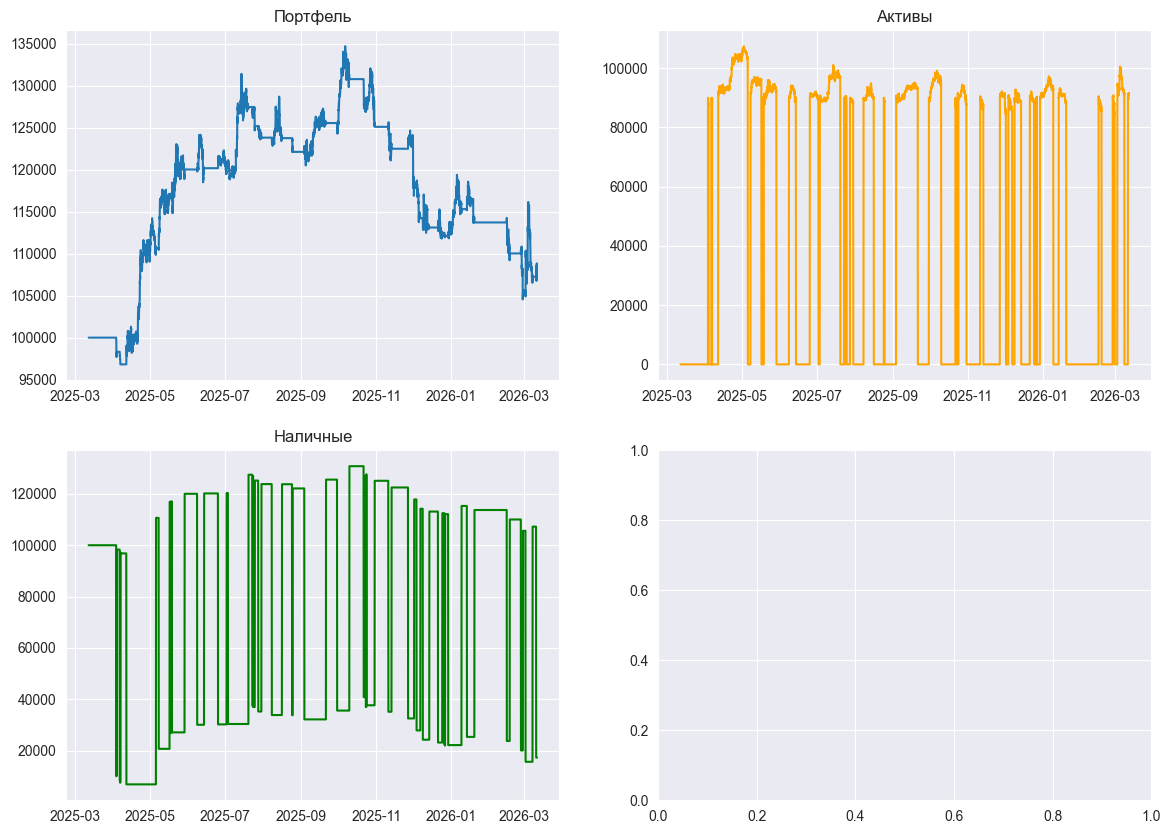

In [55]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))  # 2×2 сетки

axs[0, 0].plot(portfolio.index, portfolio['portfolio_value'])
axs[0, 0].set_title('Портфель')
axs[0, 0].grid(True)

axs[0, 1].plot(portfolio.index, portfolio['stock_value'], color='orange')
axs[0, 1].set_title('Активы')
axs[0, 1].grid(True)

axs[1, 0].plot(portfolio.index, portfolio['cash_balance'], color='green')
axs[1, 0].set_title('Наличные')
axs[1, 0].grid(True)

# colors = ['green' if PnL >= 0 else 'red' for PnL in trade_log_df['PnL']]
# axs[1, 1].bar(range(len(trade_log_df.index)), trade_log_df['PnL'], color=colors, edgecolor='black',)
# axs[1, 1].set_title('PnL')
# axs[1, 1].grid(True)

In [56]:
"""
Векторизованный расчёт стоимости портфеля.
close : pd.Series — цены закрытия
signal : pd.Series — сигналы: 1 (покупка), -1 (продажа), 0 (ничего)
initial_capital : float
"""
initial_capital = 100000
portfolio2 = pd.DataFrame(data=data[['signal', 'close']], index=data.index)

# 1. Присваиваем номер сделки: увеличивается при сигнале покупки
portfolio2['trade_id'] = (portfolio2['signal'] == 1).cumsum().shift(1)
# Но нужно, чтобы номер сделки был у всех строк от покупки до следующей покупки (или конца)
# Для этого заполняем вперёд (ffill) и обнуляем до первой покупки
#portfolio2['trade_id'] = portfolio2['trade_id'].replace(0, np.nan).ffill().fillna(0).astype(int)

# 2. Для каждой сделки определяем цену покупки (первое значение close в группе)
# Цена покупки постоянна для всей группы
portfolio2['buy_price'] = portfolio2.groupby('trade_id')['close'].transform('first')

# 3. Вычисляем множитель для каждого дня внутри сделки:
#    внутри цикла (между покупкой и продажей) множитель = 0.9 + 0.1 * (close / buy_price)
#    после продажи множитель становится константой (равной значению на день продажи)
# Для этого сначала зададим множитель везде как 1 (для дней без сделок)
portfolio2['multiplier'] = 1.0

# Для групп с trade_id > 0 (активные сделки) вычисляем динамический множитель
mask_active = portfolio2['trade_id'] > 0
portfolio2.loc[mask_active, 'multiplier'] = 0.9 + 0.1 * portfolio2.loc[mask_active, 'close'] / portfolio2.loc[mask_active, 'buy_price']

# 4. После продажи (сигнал -1) множитель должен оставаться постоянным до следующей покупки
# Найдём индексы продаж

# После вычисления множителя внутри групп создаём флаг "после продажи"
portfolio2['after_sell'] = (portfolio2[portfolio2['trade_id'] > 0]['signal'] == -1).shift(1).fillna(0).cumsum()
# Затем для каждой группы after_sell берём последнее значение множителя и распространяем его
portfolio2['multiplier_fixed'] = portfolio2.groupby(['trade_id', 'after_sell'])['multiplier'].transform('last')

# sell_idx = portfolio2[portfolio2['signal'] == -1].index
# for idx in sell_idx:
#     # Значение множителя в день продажи
#     val = portfolio2.loc[idx, 'multiplier']
#     # Найти следующий индекс после idx, где signal == 1 (следующая покупка)
#     next_buy = portfolio2[(portfolio2.index > idx) & (portfolio2['signal'] == 1)].index.min()
#     if pd.isna(next_buy):
#         next_buy = portfolio2.index[-1] + 1  # до конца
#     # Заполняем множителем val на интервале (idx, next_buy)
#     portfolio2.loc[idx:next_buy, 'multiplier'] = val

# 5. Кумулятивное произведение множителей даёт итоговую стоимость портфеля
portfolio2['portfolio'] = initial_capital * portfolio2['multiplier'].cumprod()

#portfolio2['2025-03-29': '2025-04-15'].head(20)
portfolio2['2025-04-03': '2025-04-15'].head(20)
#portfolio2['2025-04-06': '2025-09-15'].head(20)

,signal,close,trade_id,buy_price,multiplier,after_sell,multiplier_fixed,portfolio
timestamp,,,,,,,,
2025-04-03 00:00:00,0,83227.55,0.0,82932.99,1.000000,NaN,NaN,100000.000000
2025-04-03 01:00:00,0,83761.62,0.0,82932.99,1.000000,NaN,NaN,100000.000000
2025-04-03 02:00:00,0,83768.01,0.0,82932.99,1.000000,NaN,NaN,100000.000000
2025-04-03 03:00:00,0,83483.97,0.0,82932.99,1.000000,NaN,NaN,100000.000000
2025-04-03 04:00:00,0,83558.80,0.0,82932.99,1.000000,NaN,NaN,100000.000000
2025-04-03 05:00:00,0,83343.75,0.0,82932.99,1.000000,NaN,NaN,100000.000000
2025-04-03 06:00:00,0,83058.65,0.0,82932.99,1.000000,NaN,NaN,100000.000000
2025-04-03 07:00:00,1,83456.75,0.0,82932.99,1.000000,NaN,NaN,100000.000000
2025-04-03 08:00:00,0,83679.99,1.0,83679.99,1.000000,0,0.997789,100000.000000


In [57]:
"""
Векторизованный расчёт стоимости портфеля.
close : pd.Series — цены закрытия
signal : pd.Series — сигналы: 1 (покупка), -1 (продажа), 0 (ничего)
initial_capital : float
"""
initial_capital = 100000
portfolio2 = pd.DataFrame(data=data[['signal', 'close']], index=data.index)

# 1. Присваиваем номер сделки: увеличивается при сигнале покупки
portfolio2['trade_id'] = (portfolio2['signal'] == 1).cumsum().shift(1)
# Но нужно, чтобы номер сделки был у всех строк от покупки до следующей покупки (или конца)
# Для этого заполняем вперёд (ffill) и обнуляем до первой покупки
#portfolio2['trade_id'] = portfolio2['trade_id'].replace(0, np.nan).ffill().fillna(0).astype(int)

# 2. Для каждой сделки определяем цену покупки (первое значение close в группе)
# Цена покупки постоянна для всей группы
portfolio2['buy_price'] = portfolio2.groupby('trade_id')['close'].transform('first')

# 3. Вычисляем множитель для каждого дня внутри сделки:
#    внутри цикла (между покупкой и продажей) множитель = 0.9 + 0.1 * (close / buy_price)
#    после продажи множитель становится константой (равной значению на день продажи)
# Для этого сначала зададим множитель везде как 1 (для дней без сделок)
portfolio2['multiplier'] = 1.0

# Для групп с trade_id > 0 (активные сделки) вычисляем динамический множитель
mask_active = portfolio2['trade_id'] > 0
portfolio2.loc[mask_active, 'multiplier'] = 0.9 + 0.1 * portfolio2.loc[mask_active, 'close'] / portfolio2.loc[mask_active, 'buy_price']

# 4. После продажи (сигнал -1) множитель должен оставаться постоянным до следующей покупки
# Найдём индексы продаж

# # После вычисления множителя внутри групп создаём флаг "после продажи"
# portfolio2['after_sell'] = (portfolio2[portfolio2['trade_id'] > 0]['signal'] == -1).shift(1).fillna(0).cumsum()
# # Затем для каждой группы after_sell берём последнее значение множителя и распространяем его
# portfolio2['multiplier_fixed'] = portfolio2.groupby(['trade_id', 'after_sell'])['multiplier'].transform('last')

sell_idx = portfolio2[portfolio2['signal'] == -1].index
for idx in sell_idx:
    # Значение множителя в день продажи
    val = portfolio2.loc[idx, 'multiplier']
    # Найти следующий индекс после idx, где signal == 1 (следующая покупка)
    next_buy = portfolio2[(portfolio2.index > idx) & (portfolio2['signal'] == 1)].index.min()
    if pd.isna(next_buy):
        next_buy = portfolio2.index[-1] + 1  # до конца
    # Заполняем множителем val на интервале (idx, next_buy)
    portfolio2.loc[idx:next_buy, 'multiplier'] = val

# 5. Кумулятивное произведение множителей даёт итоговую стоимость портфеля
portfolio2['portfolio'] = initial_capital * portfolio2['multiplier'].cumprod()

#portfolio2['2025-03-29': '2025-04-15'].head(20)
portfolio2['2025-04-03': '2025-04-15'].head(20)
#portfolio2['2025-04-06': '2025-09-15'].head(20)

,signal,close,trade_id,buy_price,multiplier,portfolio
timestamp,,,,,,
2025-04-03 00:00:00,0,83227.55,0.0,82932.99,1.000000,100000.000000
2025-04-03 01:00:00,0,83761.62,0.0,82932.99,1.000000,100000.000000
2025-04-03 02:00:00,0,83768.01,0.0,82932.99,1.000000,100000.000000
2025-04-03 03:00:00,0,83483.97,0.0,82932.99,1.000000,100000.000000
2025-04-03 04:00:00,0,83558.80,0.0,82932.99,1.000000,100000.000000
2025-04-03 05:00:00,0,83343.75,0.0,82932.99,1.000000,100000.000000
2025-04-03 06:00:00,0,83058.65,0.0,82932.99,1.000000,100000.000000
2025-04-03 07:00:00,1,83456.75,0.0,82932.99,1.000000,100000.000000
2025-04-03 08:00:00,0,83679.99,1.0,83679.99,1.000000,100000.000000


In [58]:
# Расчет дневной доходности
data['Returns'] = data['close'].resample('D').last().pct_change()
print(f"Средняя дневная доходность: {data['Returns'].mean()*100:.4f}%")
print(f"Волатильность: {data['Returns'].std()*100:.3f}%")

Средняя дневная доходность: -0.0170%
Волатильность: 2.311%


In [59]:
initial_capital = 10000

data['returns'] = data['close'].pct_change()
data['strategy_returns'] = data['signal'].shift(1) * data['returns']
data['equity'] = (1 + data['strategy_returns']).cumprod() * initial_capital

# Вычисляем метрики эффективности
total_return = (data['equity'].iloc[-1] / initial_capital - 1) * 100
annualized_return = (data['equity'].iloc[-1] / initial_capital) ** (252 / len(data)) - 1
annualized_return *= 100

sharpe_ratio = data['strategy_returns'].mean() / data['strategy_returns'].std() * np.sqrt(252)
max_drawdown = (data['equity'] / data['equity'].cummax() - 1).min() * 100

print(f"Общая доходность: {total_return:.2f}%")
print(f"Годовая доходность: {annualized_return:.2f}%")
print(f"Коэффициент Шарпа: {sharpe_ratio:.2f}")
print(f"Максимальная просадка: {max_drawdown:.2f}%")

Общая доходность: -2.29%
Годовая доходность: -0.07%
Коэффициент Шарпа: -0.11
Максимальная просадка: -4.55%


In [60]:
data['Returns'] = data['close'].pct_change()
# Моделирование результатов стратегии
data['Strategy_Returns'] = data['signal'].shift(1) * data['Returns']
data['Cumulative_Strategy_Returns'] = (1 + data['Strategy_Returns']).cumprod()
data['Cumulative_Market_Returns'] = (1 + data['Returns']).cumprod()

# Сравнение результатов
print(f"Общая доходность стратегии: {(data['Cumulative_Strategy_Returns'].iloc[-1] - 1) * 100:.2f}%")
print(f"Общая доходность рынка: {(data['Cumulative_Market_Returns'].iloc[-1] - 1) * 100:.2f}%")

Общая доходность стратегии: -2.29%
Общая доходность рынка: -14.95%
